In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, classification_report
import joblib
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


Load data from Csv for prediction

In [2]:
data = pd.read_csv("creditcard.csv")
print(data.head())
print(data.info())
print("\nNumber of missing values:\n", data.isnull().sum())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

EDA AND Preprocessing

C:\Users\sarah\AppData\Local\Temp\ipykernel_35184\796349219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=data, palette="pastel")


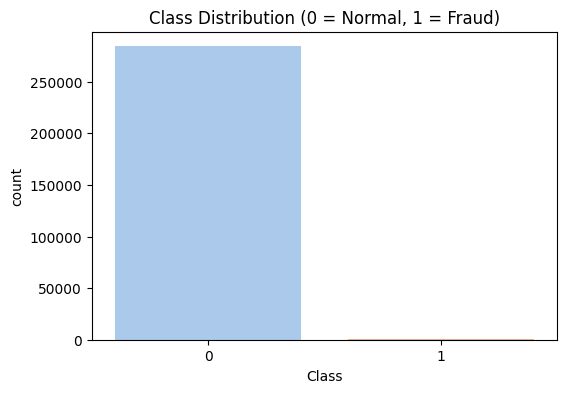


Amount column stats:


,count,mean,std,min,25%,50%,75%,max
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


In [3]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=data, palette="pastel")
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

# Amount statistics
print("\nAmount column stats:")
display(data["Amount"].describe().to_frame().T)


In [4]:

pd.set_option('display.max_columns', None)       
pd.set_option('display.width', 1000)            
corr_matrix = data.corr(numeric_only=True)
print("Correlation Matrix:")
print(corr_matrix.round(2))


Correlation Matrix:
        Time    V1    V2    V3    V4    V5    V6    V7    V8    V9   V10   V11   V12   V13   V14   V15   V16   V17   V18   V19   V20   V21   V22   V23   V24   V25   V26   V27   V28  Amount  Class
Time    1.00  0.12 -0.01 -0.42 -0.11  0.17 -0.06  0.08 -0.04 -0.01  0.03 -0.25  0.12 -0.07 -0.10 -0.18  0.01 -0.07  0.09  0.03 -0.05  0.04  0.14  0.05 -0.02 -0.23 -0.04 -0.01 -0.01   -0.01  -0.01
V1      0.12  1.00  0.00 -0.00 -0.00  0.00 -0.00 -0.00 -0.00 -0.00  0.00  0.00  0.00 -0.00 -0.00  0.00  0.00 -0.00  0.00  0.00  0.00 -0.00 -0.00  0.00 -0.00 -0.00 -0.00  0.00  0.00   -0.23  -0.10
V2     -0.01  0.00  1.00  0.00 -0.00  0.00  0.00  0.00 -0.00  0.00 -0.00  0.00 -0.00  0.00 -0.00 -0.00  0.00 -0.00  0.00 -0.00  0.00 -0.00  0.00  0.00  0.00 -0.00  0.00 -0.00 -0.00   -0.53   0.09
V3     -0.42 -0.00  0.00  1.00  0.00 -0.00  0.00  0.00 -0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 -0.00  0.00 -0.00 -0.00  0.00 -0.00 -0.00  0.00  0.00   -0.21  -0.19


Feature Engineering

In [5]:
# Create Hour column from Time
data["Hour"] = (data["Time"] // 3600) % 24

# Drop original Time (optional)
# data = data.drop(columns=["Time"])

print("✅ Added Hour feature")
display(data[["Time", "Hour", "Amount", "Class"]].head())


✅ Added Hour feature


,Time,Hour,Amount,Class
0,0.0,0.0,149.62,0
1,0.0,0.0,2.69,0
2,1.0,0.0,378.66,0
3,1.0,0.0,123.50,0
4,2.0,0.0,69.99,0


In [6]:
X = data.drop(columns=["Class"])
y = data["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (284807, 31)
Target shape: (284807,)


Model Split-Scaled

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
cols_to_scale = ["Amount", "Hour"] if "Hour" in X_train.columns else ["Amount"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("✅ Data split and scaled")


✅ Data split and scaled


Dataset BALANCING

In [8]:
print("Before SMOTE:\n", y_train.value_counts())

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:\n", y_res.value_counts())


Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


Define models to compare

In [14]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🚀 Training {name} ...")
    model.fit(X_res, y_res)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1] if hasattr(model, "predict_proba") else None
    
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    results[name] = roc
    
    print(f"{name} ROC AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred, digits=4))



🚀 Training LogisticRegression ...


c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression ROC AUC: 0.9760
              precision    recall  f1-score   support

           0     0.9998    0.9891    0.9944     56864
           1     0.1241    0.8980    0.2181        98

    accuracy                         0.9889     56962
   macro avg     0.5620    0.9435    0.6063     56962
weighted avg     0.9983    0.9889    0.9931     56962


🚀 Training RandomForest ...
RandomForest ROC AUC: 0.9728
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8265    0.8265    0.8265        98

    accuracy                         0.9994     56962
   macro avg     0.9131    0.9131    0.9131     56962
weighted avg     0.9994    0.9994    0.9994     56962


🚀 Training GradientBoosting ...
GradientBoosting ROC AUC: 0.9521
              precision    recall  f1-score   support

           0     0.9998    0.9964    0.9981     56864
           1     0.2911    0.8673    0.4359        98

    accuracy           

Test and evaluate the model


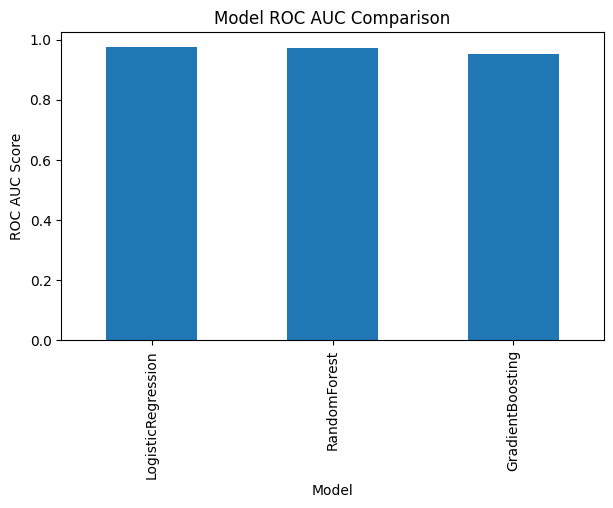

🏆 Best model: LogisticRegression (ROC AUC = 0.9760)


In [15]:
df_results = pd.DataFrame(list(results.items()), columns=["Model", "ROC_AUC"])
df_results.set_index("Model").plot(kind="bar", figsize=(7,4), legend=False)
plt.title("Model ROC AUC Comparison")
plt.ylabel("ROC AUC Score")
plt.show()

best_model_name = max(results, key=results.get)
print(f"🏆 Best model: {best_model_name} (ROC AUC = {results[best_model_name]:.4f})")
best_model = models[best_model_name]


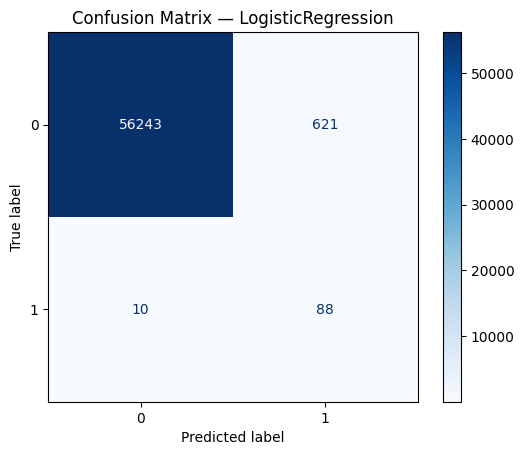

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


saving the best model 

In [17]:
joblib.dump(best_model, "best_fraud_model.pkl")
print("✅ Model saved as best_fraud_model.pkl")

✅ Model saved as best_fraud_model.pkl


In [ ]:
loaded = joblib.load("best_fraud_model.pkl")

sample = X_test_scaled.sample(10, random_state=42)
preds = loaded.predict(sample)
probas = loaded.predict_proba(sample)[:,1]

result = sample.copy()
result["predicted_class"] = preds
result["predicted_proba"] = np.round(probas, 4)

display(result)
